In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from time import perf_counter

In [2]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = mnist.data
y = mnist.target.astype(int)

In [3]:
X = X / 255
X_train, X_test, y_train, y_test = X[:8000], X[8000:12000], y[:8000], y[8000:12000]

Question 1: Linear SVM vs RBF SVM
Train and evaluate two SVM classifiers on the MNIST dataset:
1. A Linear SVM.
2. An SVM with an RBF (Radial Basis Function) kernel.
   
Keep the other hyperparameters fixed wherever possible.
For both models, report:  
•Training accuracy  
•Test accuracy  
•Training time  
•Prediction time  
Also generate and compare the confusion matrices of the two models.

In [4]:
import sklearn.svm as svm
import sklearn.metrics as metrics

time = {}
time["train"] = {}
time["test"] = {}

time["train"]["linear"] = perf_counter()
lin = svm.LinearSVC()
lin.fit(X_train, y_train)
time["train"]["linear"] = perf_counter() - time["train"]['linear']

time["train"]["rbf"] = perf_counter()
rbf = svm.SVC(kernel='rbf')
rbf.fit(X_train, y_train)
time["train"]["rbf"] = perf_counter() - time["train"]['rbf']


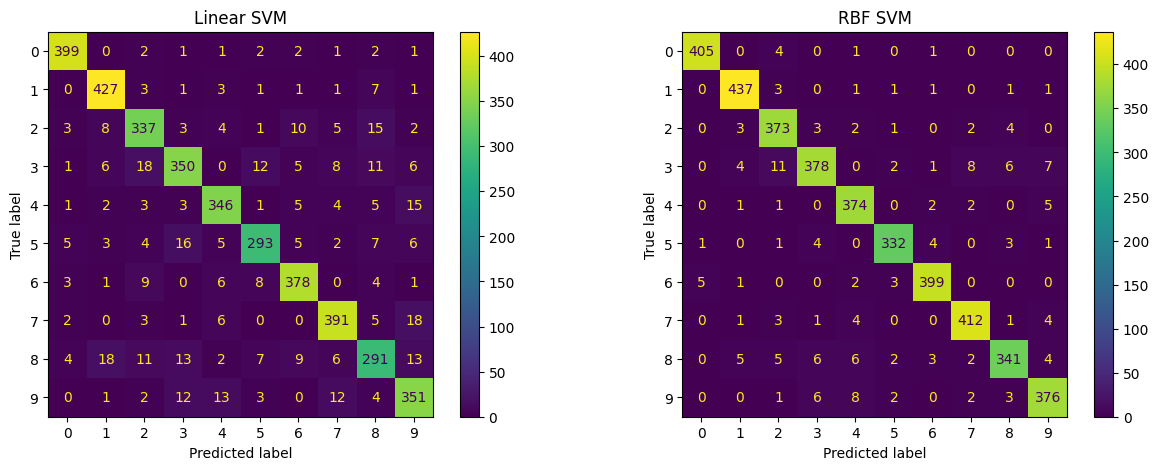

Training Time of Linear SVM: 2.5546708859992577
Prediction Time of Linear SVM: 0.018948803000057524
Accuracy of Linear SVM: 0.89075
Training Time of RBF SVM: 9.809544423000261
Prediction Time of RBF SVM: 11.754551401999379
Accuracy of RBF SVM: 0.95675


In [5]:
accuracy = {}

time["test"]["linear"] = perf_counter()
y_pred = lin.predict(X_test)
time["test"]["linear"] = perf_counter() - time["test"]["linear"]
linConf = metrics.confusion_matrix(y_test, y_pred)
accuracy["linear"] = metrics.accuracy_score(y_test, y_pred)

time["test"]["rbf"] = perf_counter()
y_pred = rbf.predict(X_test)
time["test"]["rbf"] = perf_counter() - time["test"]["rbf"]
rbfConf = metrics.confusion_matrix(y_test, y_pred)
accuracy["rbf"] = metrics.accuracy_score(y_test, y_pred)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
im = metrics.ConfusionMatrixDisplay(linConf, display_labels=range(10))
im.plot(ax = ax[0])
ax[0].set_title("Linear SVM")
im = metrics.ConfusionMatrixDisplay(rbfConf, display_labels=range(10))
im.plot(ax = ax[1])
ax[1].set_title("RBF SVM")
plt.show()

print(f"Training Time of Linear SVM: {time['train']['linear']}")
print(f"Prediction Time of Linear SVM: {time['test']['linear']}")
print(f"Accuracy of Linear SVM: {accuracy['linear']}")

print(f"Training Time of RBF SVM: {time['train']['rbf']}")
print(f"Prediction Time of RBF SVM: {time['test']['rbf']}")
print(f"Accuracy of RBF SVM: {accuracy['rbf']}")


Question 2: Effect of the Regularization Parameter C  
Using an RBF SVM, investigate the effect of the regularization parameter C.  
Use:  
C ∈{0.01, 0.1, 1, 10, 100}  
Keep the kernel and γ fixed.  
For each value of C, record:  
•Training accuracy   
•Test accuracy  
•Training time  
•Number of support vectors  
Note: Try using plt.semilogx() for better plots.  
Plot:
1. C vs. training accuracy
2. C vs. test accuracy
3. C vs. number of support vectors

In [6]:
time = {}
accuracy = {}
accuracy["train"] = {}
accuracy["test"] = {}
svs = {}

C_range = [0.01, 0.1, 1, 10, 100]
for C in C_range:
    time[C] = perf_counter()
    model = svm.SVC(C=C, kernel='rbf')
    model.fit(X_train, y_train)
    time[C] = perf_counter() - time[C]
    y_pred = model.predict(X_train)
    accuracy["train"][C] = metrics.accuracy_score(y_train, y_pred)
    y_pred = model.predict(X_test)
    accuracy["test"][C] = metrics.accuracy_score(y_test, y_pred)
    svs[C] = model.n_support_.sum()


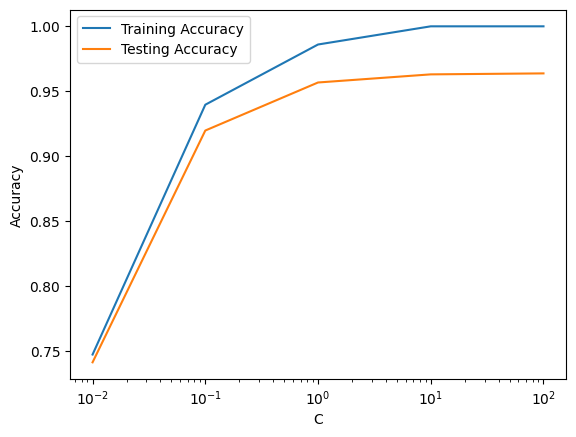

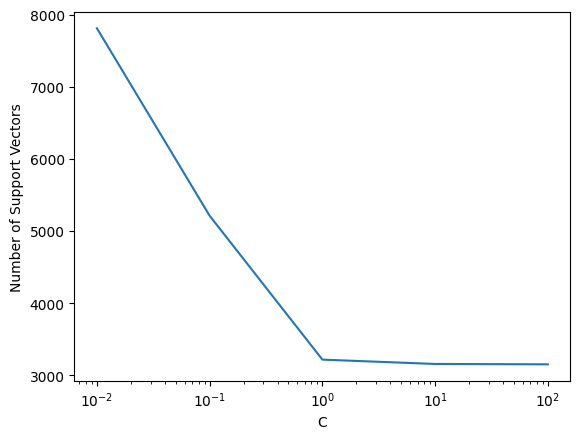

In [7]:
plt.semilogx(C_range,[accuracy["train"][C] for C in C_range], label="Training Accuracy")
plt.semilogx(C_range,[accuracy["test"][C] for C in C_range], label="Testing Accuracy")
plt.xlabel("C")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.semilogx(C_range,[svs[C] for C in C_range])
plt.xlabel("C")
plt.ylabel("Number of Support Vectors")
plt.show()

Question 3: Effect of the RBF Parameter γ  
Using an RBF SVM, investigate the effect of the kernel parameter γ.  
Use:  
γ ∈{10−4, 10−3, 10−2, 10−1}  
Keep C = 1 fixed.  
For each value of γ, record:  
•Training accuracy  
•Test accuracy  
•Training time  
•Number of support vectors  
Plot:  
1. γ vs. training accuracy  
2. γ vs. test accuracy  
3. γ vs. number of support vectors  
Bonus: Try this without normalizing if you want.  

In [8]:
time = {}
accuracy = {}
accuracy["train"] = {}
accuracy["test"] = {}
svs = {}

gammas = [0.0001, 0.001, 0.01, 0.1]
for g in gammas:
    time[g] = perf_counter()
    model = svm.SVC(kernel='rbf', C=1, gamma=g)
    model.fit(X_train, y_train)
    time[g] = perf_counter() - time[g]
    y_pred = model.predict(X_train)
    accuracy["train"][g] = metrics.accuracy_score(y_train, y_pred)
    y_pred = model.predict(X_test)
    accuracy["test"][g] = metrics.accuracy_score(y_test, y_pred)
    svs[g] = model.n_support_.sum()

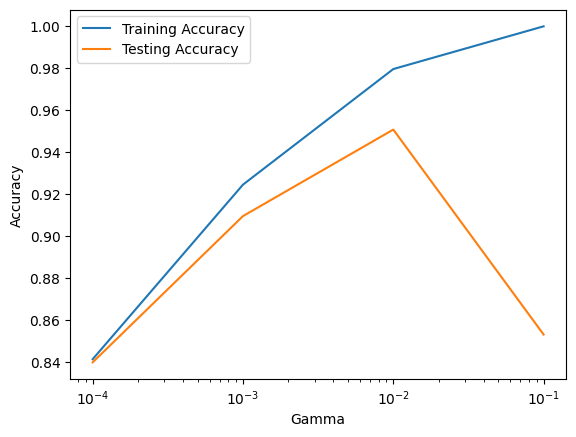

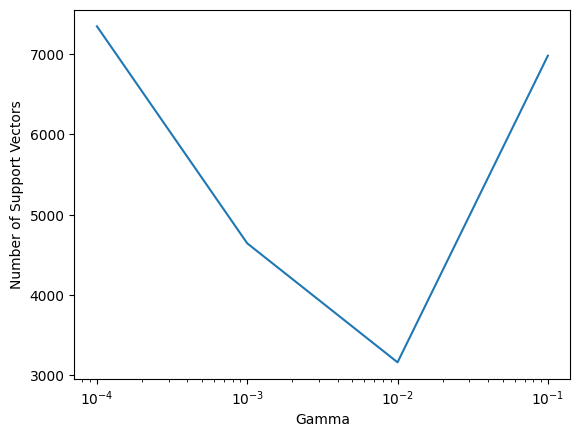

In [9]:
plt.semilogx(gammas,[accuracy["train"][g] for g in gammas], label="Training Accuracy")
plt.semilogx(gammas,[accuracy["test"][g] for g in gammas], label="Testing Accuracy")
plt.xlabel("Gamma")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.semilogx(gammas,[svs[g] for g in gammas])
plt.xlabel("Gamma")
plt.ylabel("Number of Support Vectors")
plt.show()

Question 4: SVM vs. Logistic Regression  
Using the results from the previous Logistic Regression lab, compare the performance of Logistic Regression with the SVM model from this lab.  
Compare their confusion matrices and accuracies.  

Accuracy: 0.90725


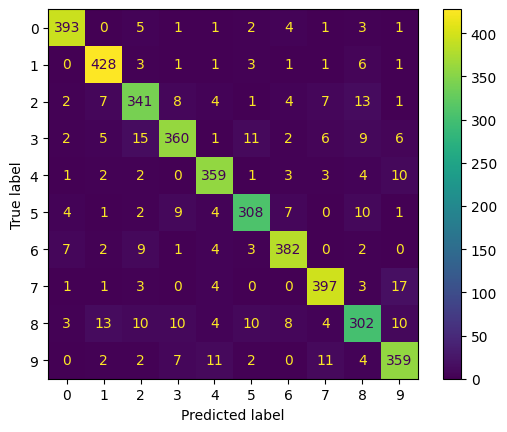

In [17]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print(f"Accuracy: {metrics.accuracy_score(y_test, y_pred)}")
metrics.ConfusionMatrixDisplay(metrics.confusion_matrix(y_test, y_pred)).plot()
plt.show()

Accuracy of RBF SVM is 0.95675 while accuracy of logistic regression is 0.90725. Logistic Regression finds a linear hyperplane to separate the data into classes, while RBF SVM maps the data into infinite dimensions, creating flexible boundaries. This is why RBF SVM has better accuracy.

Question 5: Visualizing Support Vectors  
Train an RBF SVM on the MNIST training set and extract the support vectors using the trained model.  
Visualize a suitable number of support vectors as 28 ×28 grayscale images.  
Note: If the full MNIST dataset produces too many support vectors to visualize clearly, select a representative subset of support vectors for visualization.  

In [13]:
model = svm.SVC(kernel='rbf')
model.fit(X, y)

SVC()

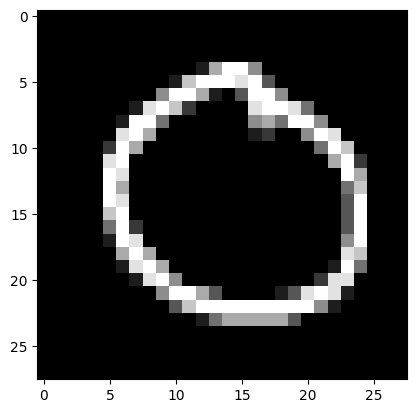

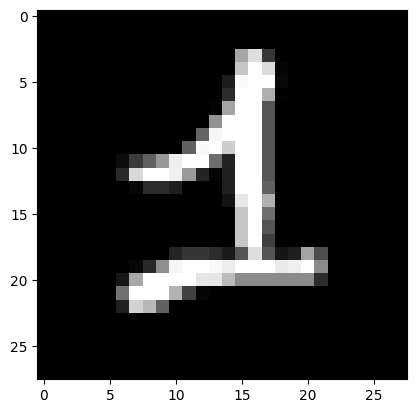

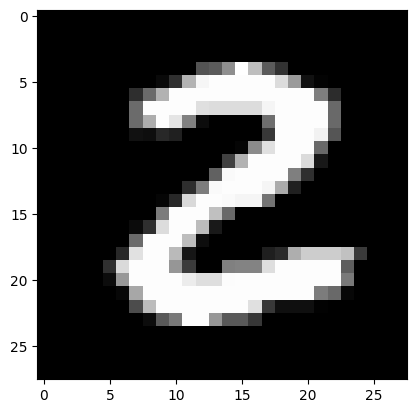

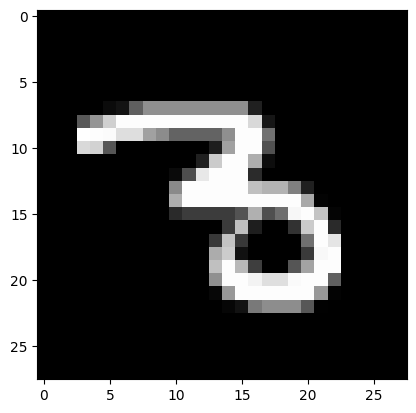

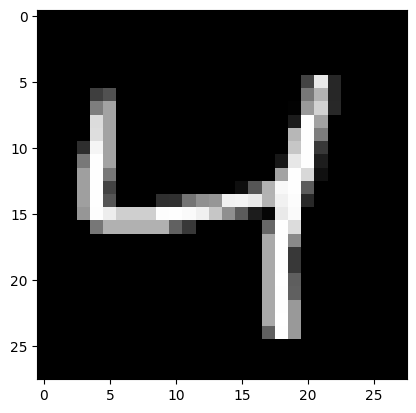

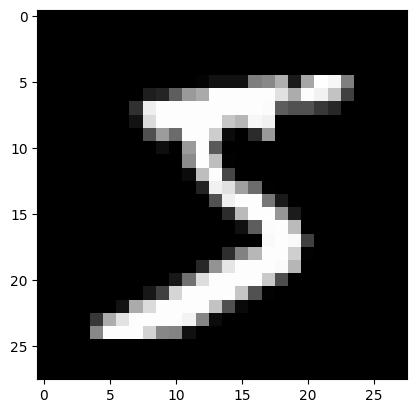

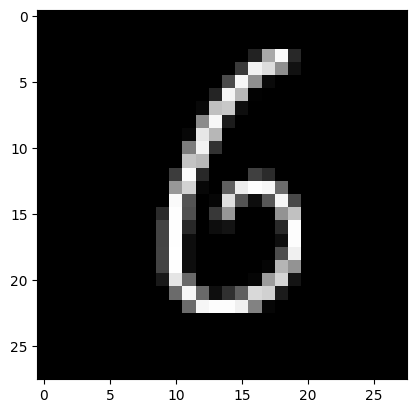

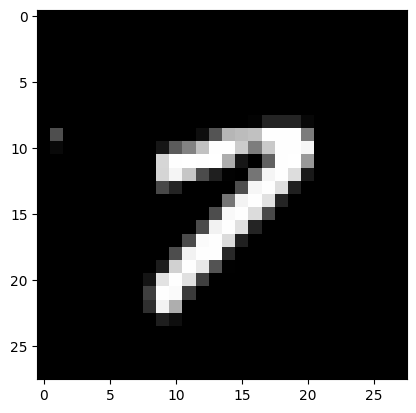

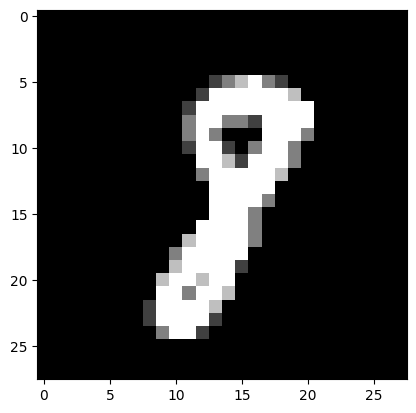

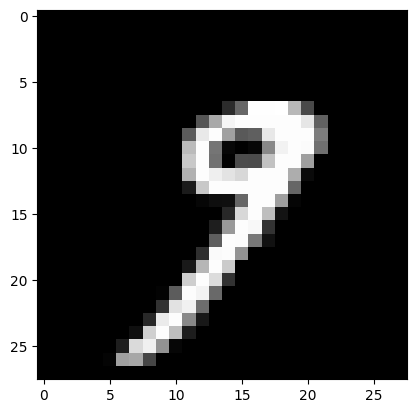

In [33]:
vectors = model.support_vectors_
indices = model.support_
num = model.n_support_
vlabels = y[indices]

for d in range(10):
    v = np.where(vlabels == d)[0][0]
    plt.imshow(vectors[v].reshape(28, 28), cmap="gray")
    plt.show()
